In [1]:
from google.colab import files
uploaded = files.upload()


Saving Online Retail.xlsx to Online Retail.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [5]:
import io
df = pd.read_excel(io.BytesIO(uploaded['Online Retail.xlsx']))

In [6]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [7]:
df.fillna(0,inplace=True)

In [8]:
print(df.isnull().sum(

))

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [9]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  541909 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   541909 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [11]:
df.describe(

)

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,11476.974671
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,0.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,12352.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,14382.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16255.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,6777.908326


In [13]:
df["TotalAmount"]=df["Quality"]=df["UnitPrice"]

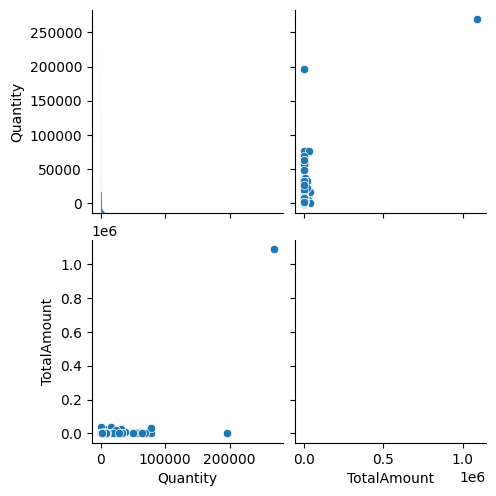

In [14]:
customer = df.groupby("CustomerID")[["Quantity","TotalAmount"]].sum()

sns.pairplot(customer)
plt.show()

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer)


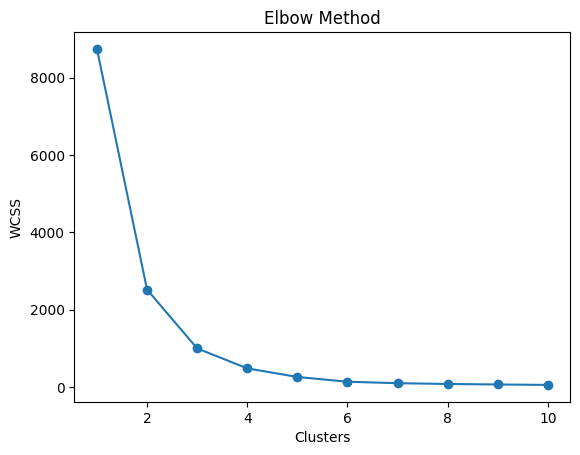

In [16]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()


In [17]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

customer["Cluster"] = clusters



In [18]:
print(kmeans.cluster_centers_)

[[-3.81583859e-02 -1.58778087e-02]
 [ 4.33661010e+01  6.59214374e+01]
 [ 1.23080778e+01  3.33756406e-01]]


In [19]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score =", score)


Silhouette Score = 0.9808216705425638


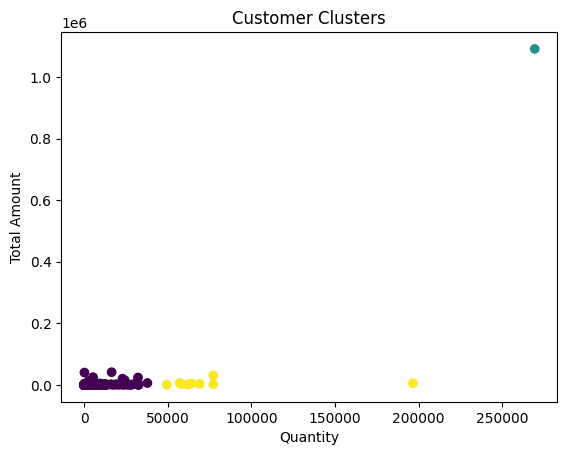

In [20]:
plt.scatter(customer["Quantity"],
            customer["TotalAmount"],
            c=customer["Cluster"],
            cmap="viridis")

plt.title("Customer Clusters")
plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.show()


In [21]:
print(customer["Cluster"].value_counts())

Cluster
0    4362
2      10
1       1
Name: count, dtype: int64


In [22]:
print(customer.groupby("Cluster").mean())

              Quantity   TotalAmount
Cluster                             
0           947.580238  3.087801e+02
1        269562.000000  1.090984e+06
2         77354.300000  6.092112e+03
